# Prepoznavanje emocija iz teksta

Finalna demo sveska projekta iz Mašinskog učenja.

**Članovi tima:**  
- Sonja Mijailović  
- Matija Stanković  
- Dimitrije Vranić  

Cilj projekta je klasifikacija tekstova u šest emocija: `joy`, `sadness`, `anger`, `fear`, `love` i `surprise`.

U projektu se porede klasične metode mašinskog učenja, LSTM, GRU i transformer model.

## 1. Učitavanje biblioteka

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display, Image

## 2. Kratak pregled skupa podataka

Koriste se odvojeni trening, validacioni i test skup.  
Pre modelovanja su provereni nedostajući podaci, duplikati i preklapanja između skupova.

In [2]:
train = pd.read_csv("data/processed/train.txt", sep=";", header=None, names=["text", "emotion"])
val = pd.read_csv("data/processed/val.txt", sep=";", header=None, names=["text", "emotion"])
test = pd.read_csv("data/processed/test.txt", sep=";", header=None, names=["text", "emotion"])

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

Train: (15983, 2)
Validation: (1997, 2)
Test: (2000, 2)


### Raspodela emocija u trening skupu

Pošto klase nisu potpuno izbalansirane, pored Accuracy metrike koristimo i **Macro F1**, koji svakoj klasi daje jednaku važnost.

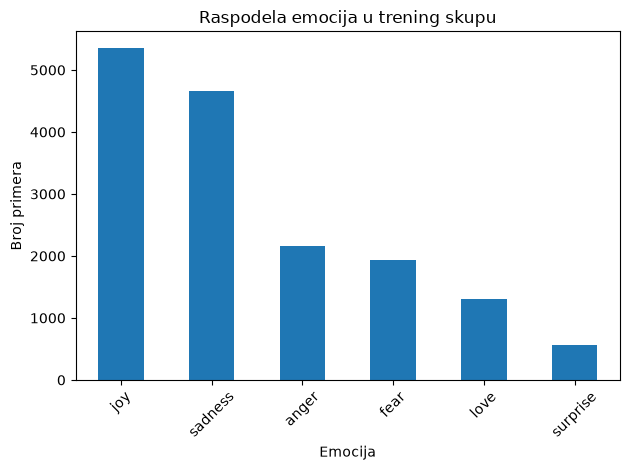

In [3]:
train["emotion"].value_counts().plot(kind="bar")
plt.xlabel("Emocija")
plt.ylabel("Broj primera")
plt.title("Raspodela emocija u trening skupu")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Klasični modeli

Tekstovi su predstavljeni pomoću TF-IDF reprezentacije.

Isprobani su:
- Logistic Regression
- Multinomial Naive Bayes
- Linear SVM
- Random Forest

### Rezultati osnovnih klasičnih modela

In [4]:
baseline_results = pd.read_csv("results/comparable_results/baseline_results.csv")
display(baseline_results)

,model,accuracy,macro_f1
0,Logistic Regression,0.8603,0.8109
1,Naive Bayes,0.6415,0.3548
2,Linear SVM,0.9009,0.8734
3,Random Forest,0.8753,0.8499


Najbolje osnovne rezultate imao je Linear SVM, pa su za najperspektivnije modele dodatno podešavani hiperparametri pomoću `GridSearchCV`.

### Rezultati podešavanja hiperparametara

GridSearchCV je izvođen samo na trening skupu, uz 3-fold unakrsnu validaciju.  
Poseban validacioni skup je zatim korišćen za poređenje najboljih podešenih modela.

In [5]:
tuned_results = pd.read_csv("results/comparable_results/tuned_results.csv")
display(tuned_results)

,model,accuracy,macro_f1
0,Linear SVM tuned,0.901853,0.879462
1,Logistic Regression tuned,0.894842,0.870970


Za Linear SVM najbolji hiperparametri bili su:

- `C = 0.5`
- `class_weight = "balanced"`
- `ngram_range = (1, 1)`

Nakon izbora modela, trening i validacioni skup su spojeni i finalni SVM je obučen na njihovoj uniji.  
Test skup je korišćen samo za konačnu evaluaciju.

## 4. Konačni rezultat klasičnog modela

In [6]:
final_results = pd.read_csv("results/comparable_results/final_results.csv")

final_classical = final_results[
    final_results["model"] == "Linear SVM"
]

display(final_classical)

,model,accuracy,macro_f1
0,Linear SVM,0.897,0.8536


Konačni Linear SVM ostvario je približno:

- Accuracy = **0.897**
- Macro F1 = **0.854**

### Matrica konfuzije finalnog SVM modela

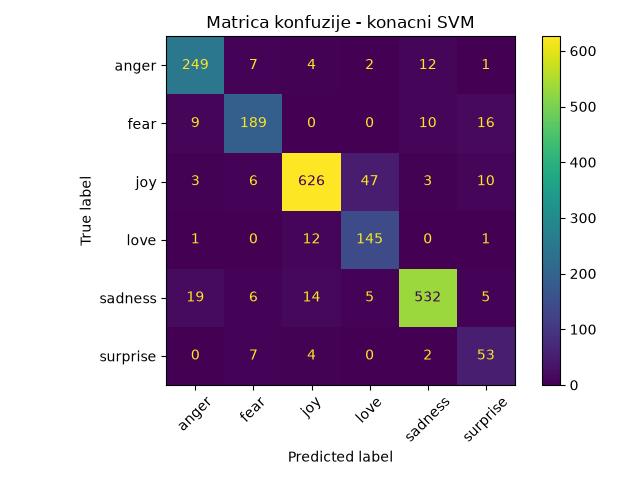

In [7]:
display(Image(filename="results/SVM/confusion_matrix_final_svm.png"))

## 5. Demonstracija predikcija finalnog SVM modela

Učitava se već sačuvani Pipeline, koji sadrži TF-IDF vektorizator i Linear SVM.

In [8]:
model = joblib.load("models/classical_ml/final_svm.joblib")
print("Finalni SVM model je učitan.")

Finalni SVM model je učitan.


In [9]:
primeri = [
    "i feel very happy today",
    "i am scared about what will happen",
    "i feel deeply sad and lonely",
    "i am so angry right now"
]

predikcije = model.predict(primeri)

for tekst, emocija in zip(primeri, predikcije):
    print(tekst, "->", emocija)

i feel very happy today -> joy
i am scared about what will happen -> fear
i feel deeply sad and lonely -> sadness
i am so angry right now -> anger


## 6. LSTM

Za sekvencijalno modelovanje teksta korišćen je LSTM. Najbolja konfiguracija ima embedding dimenziju 128, skriveno stanje dimenzije 256, dva LSTM sloja i dropout 0.5. Sačuvani checkpoint pored težina sadrži i vokabular, redosled klasa i maksimalnu dužinu sekvence, pa se novi tekst obrađuje potpuno isto kao tokom treninga.

In [10]:
import torch

from RNN import emotion_utils

load_lstm_checkpoint = emotion_utils.load_lstm_checkpoint
predict_emotions = emotion_utils.predict_emotions

lstm_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm_model, lstm_checkpoint = load_lstm_checkpoint(
    "models/rnn/lstm_emotion.pth", device=lstm_device
)

print(f"LSTM model {lstm_checkpoint['model_name']} je učitan na {lstm_device}.")
print("Konfiguracija:", lstm_checkpoint["config"])

LSTM model LSTM_20 je učitan na cpu.
Konfiguracija: {'embedding_dim': 128, 'hidden_size': 256, 'num_layers': 2, 'dropout': 0.5, 'learning_rate': 0.001}


In [11]:
lstm_predikcije = predict_emotions(lstm_model, primeri, lstm_checkpoint)

for tekst, (emocija, pouzdanost) in zip(primeri, lstm_predikcije):
    print(f"{tekst} -> {emocija} ({pouzdanost:.1%})")

i feel very happy today -> joy (100.0%)
i am scared about what will happen -> fear (99.6%)
i feel deeply sad and lonely -> sadness (99.9%)
i am so angry right now -> anger (93.2%)


Na test skupu LSTM ostvaruje **Accuracy = 0.9035** i **Macro F1 = 0.8659**.

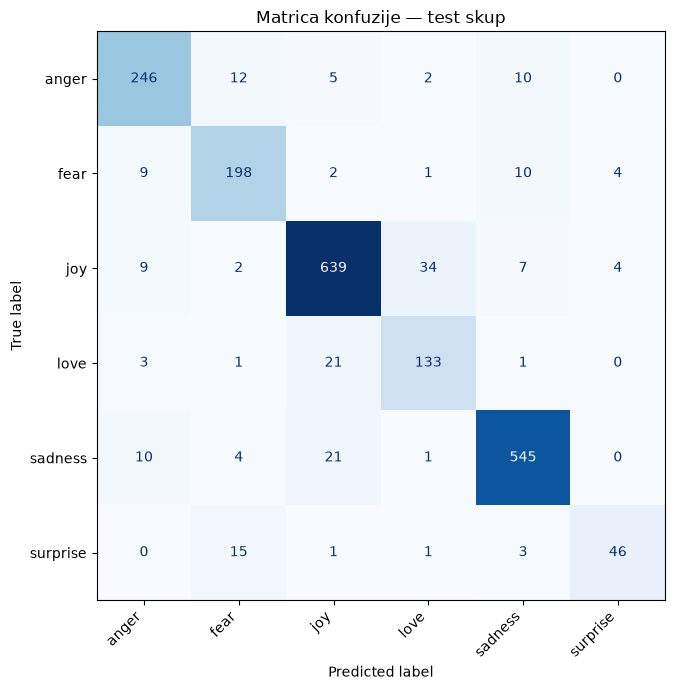

In [12]:
display(Image(filename="results/LSTM/lstm_confusion_matrix.png"))

## 7. Transformer modeli

Za klasifikaciju emocija korišćena su dva pretrained Transformer modela:

- BERT (`bert-base-uncased`)
- DistilBERT (`distilbert-base-uncased`)

Oba modela su dodatno trenirana na našem skupu podataka za klasifikaciju u šest klasa.


In [14]:
import torch

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    DistilBertTokenizer,
    DistilBertForSequenceClassification
)
from tranformer_models.transformer_utils import predict_emotions

import torch

transformer_device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", transformer_device)

Device: cpu


## BERT

Za klasifikaciju emocija korišćen je pretrained `bert-base-uncased` model sa dodatim klasifikacionim slojem za šest emocija.

Najbolja konfiguracija dobijena podešavanjem hiperparametara bila je:

- learning rate = `3e-5`
- batch size = `16`
- epochs = `3`

Najbolji model iz treninga je sačuvan i koristi se u nastavku za demonstraciju predikcija.

In [15]:
bert_tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

bert_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=6
)

bert_state_dict = torch.load(
    "models/transformer/bert_model.pt",
    map_location=transformer_device
)

bert_model.load_state_dict(bert_state_dict)

bert_model.to(transformer_device)
bert_model.eval()

print("BERT model je učitan.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\dimit\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dimit\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model je učitan.


### Demonstracija predikcija BERT modela

Model se primenjuje na nekoliko novih rečenica, a pored predikovane emocije prikazuje se i verovatnoća koju model dodeljuje izabranoj klasi.

In [16]:
bert_predikcije = predict_emotions(
    bert_model,
    bert_tokenizer,
    primeri,
    transformer_device
)

for tekst, (emocija, pouzdanost) in zip(
    primeri,
    bert_predikcije
):
    print(
        f"{tekst} -> "
        f"{emocija} "
        f"({pouzdanost:.1%})"
    )

i feel very happy today -> joy (99.8%)
i am scared about what will happen -> fear (97.0%)
i feel deeply sad and lonely -> sadness (99.7%)
i am so angry right now -> anger (98.9%)


## DistilBERT

Pored BERT modela korišćen je i DistilBERT, kompaktnija i brža verzija BERT-a dobijena postupkom knowledge distillation.

Najbolja konfiguracija dobijena podešavanjem hiperparametara bila je:

- learning rate = `5e-5`
- batch size = `16`
- epochs = `3`

Najbolji rezultat na validacionom skupu ostvaren je u trećoj epohi.

In [17]:
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification
)

distilbert_tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

distilbert_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=6
)

distilbert_state_dict = torch.load(
    "models/transformer/distilbert_model.pt",
    map_location=transformer_device
)

distilbert_model.load_state_dict(
    distilbert_state_dict
)

distilbert_model.to(transformer_device)
distilbert_model.eval()

print("DistilBERT model je učitan.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\dimit\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dimit\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model je učitan.


### Demonstracija predikcija DistilBERT modela

Učitava se sačuvani DistilBERT model i koriste isti test primeri kao kod ostalih modela, kako bi poređenje predikcija bilo direktno.

In [18]:
distilbert_predikcije = predict_emotions(
    distilbert_model,
    distilbert_tokenizer,
    primeri,
    transformer_device
)

for tekst, (emocija, pouzdanost) in zip(
    primeri,
    distilbert_predikcije
):
    print(
        f"{tekst} -> "
        f"{emocija} "
        f"({pouzdanost:.1%})"
    )

i feel very happy today -> joy (99.9%)
i am scared about what will happen -> fear (99.0%)
i feel deeply sad and lonely -> sadness (99.9%)
i am so angry right now -> anger (98.7%)


In [19]:
comparison = pd.DataFrame({
    "text": primeri,
    "BERT": [
        emocija
        for emocija, _ in bert_predikcije
    ],
    "BERT confidence": [
        f"{pouzdanost:.1%}"
        for _, pouzdanost in bert_predikcije
    ],
    "DistilBERT": [
        emocija
        for emocija, _ in distilbert_predikcije
    ],
    "DistilBERT confidence": [
        f"{pouzdanost:.1%}"
        for _, pouzdanost in distilbert_predikcije
    ]
})
print("BERT VS DistilBERT")
display(comparison)

BERT VS DistilBERT


,text,BERT,BERT confidence,DistilBERT,DistilBERT confidence
0,i feel very happy today,joy,99.8%,joy,99.9%
1,i am scared about what will happen,fear,97.0%,fear,99.0%
2,i feel deeply sad and lonely,sadness,99.7%,sadness,99.9%
3,i am so angry right now,anger,98.9%,anger,98.7%


## 8. Poređenje svih modela


,model,accuracy,macro_f1
0,Linear SVM,0.8970,0.853600
1,BERT,0.9310,0.890937
2,DistilBERT,0.9320,0.889258
3,LSTM,0.9035,0.865920


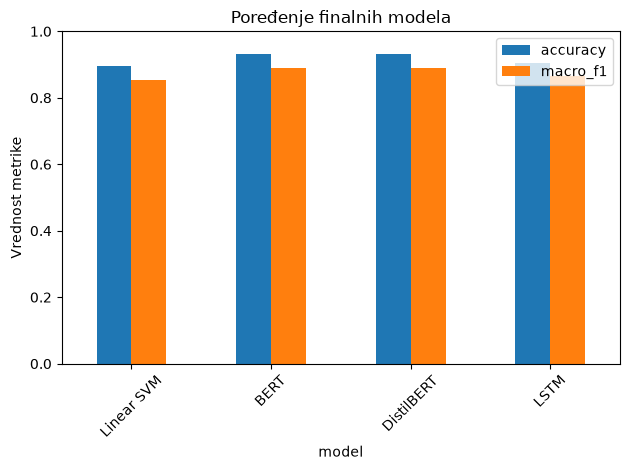

In [20]:
final_results = pd.read_csv("results/comparable_results/final_results.csv")
display(final_results)

final_results.set_index("model")[["accuracy", "macro_f1"]].plot(kind="bar")
plt.ylabel("Vrednost metrike")
plt.title("Poređenje finalnih modela")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 9. Zaključak

U projektu je upoređeno više različitih pristupa za klasifikaciju emocija u tekstu: klasični modeli mašinskog učenja, rekurentne neuronske mreže i Transformer modeli.

Klasični Linear SVM pokazao se kao veoma jak baseline, sa Accuracy vrednošću od približno **0.897** i Macro F1 rezultatom od približno **0.854**.

LSTM i GRU modeli ostvarili su nešto bolje rezultate od klasičnih pristupa, što pokazuje prednost sekvencijalnog modelovanja teksta. LSTM je na test skupu ostvario Accuracy od približno **0.904** i Macro F1 od približno **0.866**.

Najbolje rezultate ostvarili su Transformer modeli. BERT je postigao Accuracy od približno **0.931** i Macro F1 od približno **0.891**, dok je DistilBERT ostvario veoma slične performanse uz manju veličinu modela i manju računarsku zahtevnost.

Rezultati pokazuju da složeniji modeli generalno daju bolje performanse, ali uz veću cenu treniranja i izvođenja. BERT daje najbolje ukupne rezultate, dok DistilBERT predstavlja veoma dobar kompromis između kvaliteta predikcije i efikasnosti.

Posebno je važno korišćenje Macro F1 metrike, jer skup podataka nije potpuno balansiran i ova metrika daje jednaku važnost svim klasama emocija, uključujući i ređe zastupljene klase.

Na osnovu dobijenih rezultata može se zaključiti da Transformer modeli predstavljaju najuspešniji pristup za dati problem klasifikacije emocija, dok klasični i rekurentni modeli ostaju korisni kao jednostavnije i manje zahtevne alternative.
